# Extraction des compétences techniques

## Objectif

Cette étape extrait automatiquement les compétences mentionnées dans les offres d'emploi.

La méthode repose sur un dictionnaire de compétences et des expressions régulières. Elle permet de :

- mesurer la fréquence de chaque compétence ;
- comparer les compétences selon les métiers ;
- étudier le salaire médian associé aux compétences ;
- produire un fichier exploitable pour la modélisation et le Tech Skills Index.

## 1. Imports

In [3]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd

## 2. Chargement des données

In [6]:
DATA_PATH = Path("offres_emploi_tech_eda.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Le fichier offres_emploi_tech_eda.csv est introuvable."
    )

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

required_columns = {
    "id",
    "titre",
    "description",
    "categorie_metier",
    "salaire_moy",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    missing_list = ", ".join(sorted(missing_columns))
    raise ValueError(f"Colonnes manquantes : {missing_list}")

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 922 lignes × 21 colonnes


,id,titre,description,type_contrat,experience,ville,secteur,entreprise,salaire_min,salaire_max,...,date_publication,mot_cle_source,salaire_moy_avant_correction,salaire_corrige_heuristique,departement,ville_clean,contrat_simplifie,zone_geographique,categorie_metier,source_classification
0,210LQML,Chef de projet informatique DATA (H/F),Rattaché(e) au Directeur du service informatiq...,CDI,1 An(s) - Sur poste similaire,55 - BRAS-SUR-MEUSE,Commerce de gros (commerce interentreprises) d...,EMC2,NaN,NaN,...,2026-06-29 14:04:21.520000+00:00,machine learning,NaN,False,55.0,BRAS-SUR-MEUSE,CDI,BRAS-SUR-MEUSE,Data Project / Product,titre
1,210LNTS,Data manager (F/H),En intégrant une communauté d'experts passionn...,CDI,3 An(s),31 - Toulouse,Activités des agences de travail temporaire,RANDSTAD PROFESSIONAL,40000.0,0.0,...,2026-06-29 13:03:07.107000+00:00,data engineer,20000.0,True,31.0,Toulouse,CDI,Toulouse Métropole,Data Management / Governance,titre
2,210LGWN,Data engineer (BI) - H/F/X (H/F),Nous recherchons un(e) Data Engineer passionné...,CDI,4 An(s),93 - ST DENIS,Vente à distance sur catalogue général,VENTE PRIVEE.COM,NaN,NaN,...,2026-06-29 11:01:04.587000+00:00,data engineer,NaN,False,93.0,ST DENIS,CDI,Île-de-France,Data Engineer,titre
3,210LDDF,Consultant BI / Décisionnel (H/F),Vous souhaitez rejoindre un environnement où l...,CDI,4 An(s),84 - Avignon,Conseil pour les affaires et autres conseils d...,GROUPAGORA,40000.0,0.0,...,2026-06-29 10:18:03.314000+00:00,business intelligence,20000.0,True,84.0,Avignon,CDI,Avignon,Data Analyst / BI,titre
4,210LCDC,Chargé de projet data analyst (H/F),Chargé(e) de Projets / Data Analyst (CDD) - Pa...,CDD - 6 Mois,2 An(s),75 - PARIS,Commerce de gros (commerce interentreprises) d...,REXEL FRANCE,35000.0,0.0,...,2026-06-29 09:58:36.173000+00:00,data analyst,17500.0,True,75.0,Paris,CDD,Île-de-France,Data Analyst / BI,titre


## 3. Dictionnaire des compétences

In [9]:
SKILLS = {
    "Python": {
        "famille": "Langages",
        "patterns": [r"\bpython\b"],
    },
    "R": {
        "famille": "Langages",
        "patterns": [
            r"\brstudio\b",
            r"\blangage r\b",
            r"\bprogrammation r\b",
            r"\br programming\b",
        ],
    },
    "Java": {
        "famille": "Langages",
        "patterns": [r"\bjava\b"],
    },
    "Scala": {
        "famille": "Langages",
        "patterns": [r"\bscala\b"],
    },
    "C++": {
        "famille": "Langages",
        "patterns": [r"(?<!\w)c\+\+(?!\w)"],
    },
    "C#": {
        "famille": "Langages",
        "patterns": [r"(?<!\w)c#(?!\w)", r"\bc sharp\b"],
    },
    "JavaScript": {
        "famille": "Langages",
        "patterns": [r"\bjavascript\b"],
    },
    "TypeScript": {
        "famille": "Langages",
        "patterns": [r"\btypescript\b"],
    },
    "Bash": {
        "famille": "Langages",
        "patterns": [r"\bbash\b", r"\bshell scripting\b"],
    },
    "SQL": {
        "famille": "Bases de données",
        "patterns": [r"\bsql\b", r"\bpl/sql\b", r"\bt-sql\b"],
    },
    "PostgreSQL": {
        "famille": "Bases de données",
        "patterns": [r"\bpostgresql\b", r"\bpostgres\b"],
    },
    "MySQL": {
        "famille": "Bases de données",
        "patterns": [r"\bmysql\b"],
    },
    "Oracle": {
        "famille": "Bases de données",
        "patterns": [r"\boracle\b"],
    },
    "SQL Server": {
        "famille": "Bases de données",
        "patterns": [r"\bsql server\b"],
    },
    "MongoDB": {
        "famille": "Bases de données",
        "patterns": [r"\bmongodb\b"],
    },
    "NoSQL": {
        "famille": "Bases de données",
        "patterns": [r"\bnosql\b"],
    },
    "Snowflake": {
        "famille": "Bases de données",
        "patterns": [r"\bsnowflake\b"],
    },
    "BigQuery": {
        "famille": "Bases de données",
        "patterns": [r"\bbigquery\b", r"\bbig query\b"],
    },
    "Power BI": {
        "famille": "BI et visualisation",
        "patterns": [r"\bpower bi\b", r"\bpowerbi\b"],
    },
    "Tableau": {
        "famille": "BI et visualisation",
        "patterns": [r"\btableau software\b", r"\btableau desktop\b"],
    },
    "Qlik": {
        "famille": "BI et visualisation",
        "patterns": [r"\bqlik\b", r"\bqlikview\b", r"\bqlik sense\b"],
    },
    "Looker": {
        "famille": "BI et visualisation",
        "patterns": [r"\blooker\b"],
    },
    "Excel": {
        "famille": "BI et visualisation",
        "patterns": [r"\bexcel\b"],
    },
    "SAS": {
        "famille": "BI et visualisation",
        "patterns": [r"\bsas\b"],
    },
    "Spark": {
        "famille": "Data Engineering",
        "patterns": [r"\bspark\b", r"\bpyspark\b"],
    },
    "Hadoop": {
        "famille": "Data Engineering",
        "patterns": [r"\bhadoop\b"],
    },
    "Kafka": {
        "famille": "Data Engineering",
        "patterns": [r"\bkafka\b"],
    },
    "Airflow": {
        "famille": "Data Engineering",
        "patterns": [r"\bairflow\b"],
    },
    "dbt": {
        "famille": "Data Engineering",
        "patterns": [r"\bdbt\b", r"\bdata build tool\b"],
    },
    "Databricks": {
        "famille": "Data Engineering",
        "patterns": [r"\bdatabricks\b"],
    },
    "Talend": {
        "famille": "Data Engineering",
        "patterns": [r"\btalend\b"],
    },
    "ETL / ELT": {
        "famille": "Data Engineering",
        "patterns": [r"\betl\b", r"\belt\b"],
    },
    "Data Warehouse": {
        "famille": "Data Engineering",
        "patterns": [
            r"\bdata warehouse\b",
            r"\bdatawarehouse\b",
            r"\bentrepot de donnees\b",
        ],
    },
    "AWS": {
        "famille": "Cloud",
        "patterns": [r"\baws\b", r"\bamazon web services\b"],
    },
    "Azure": {
        "famille": "Cloud",
        "patterns": [r"\bazure\b", r"\bmicrosoft azure\b"],
    },
    "GCP": {
        "famille": "Cloud",
        "patterns": [r"\bgcp\b", r"\bgoogle cloud\b"],
    },
    "Docker": {
        "famille": "DevOps",
        "patterns": [r"\bdocker\b"],
    },
    "Kubernetes": {
        "famille": "DevOps",
        "patterns": [r"\bkubernetes\b", r"\bk8s\b"],
    },
    "Git": {
        "famille": "DevOps",
        "patterns": [r"\bgit\b", r"\bgithub\b", r"\bgitlab\b"],
    },
    "CI/CD": {
        "famille": "DevOps",
        "patterns": [
            r"\bci/cd\b",
            r"\bintegration continue\b",
            r"\bdeploiement continu\b",
        ],
    },
    "Linux": {
        "famille": "DevOps",
        "patterns": [r"\blinux\b"],
    },
    "Terraform": {
        "famille": "DevOps",
        "patterns": [r"\bterraform\b"],
    },
    "scikit-learn": {
        "famille": "Machine Learning",
        "patterns": [r"\bscikit-learn\b", r"\bsklearn\b"],
    },
    "TensorFlow": {
        "famille": "Machine Learning",
        "patterns": [r"\btensorflow\b"],
    },
    "PyTorch": {
        "famille": "Machine Learning",
        "patterns": [r"\bpytorch\b"],
    },
    "XGBoost": {
        "famille": "Machine Learning",
        "patterns": [r"\bxgboost\b"],
    },
    "MLflow": {
        "famille": "Machine Learning",
        "patterns": [r"\bmlflow\b"],
    },
    "Machine Learning": {
        "famille": "Machine Learning",
        "patterns": [
            r"\bmachine learning\b",
            r"\bapprentissage automatique\b",
        ],
    },
    "Deep Learning": {
        "famille": "Machine Learning",
        "patterns": [
            r"\bdeep learning\b",
            r"\bapprentissage profond\b",
        ],
    },
    "NLP": {
        "famille": "IA générative et NLP",
        "patterns": [
            r"\bnlp\b",
            r"\btraitement automatique du langage\b",
            r"\bnatural language processing\b",
        ],
    },
    "LLM": {
        "famille": "IA générative et NLP",
        "patterns": [
            r"\bllm\b",
            r"\blarge language model\b",
            r"\bmodele de langage\b",
        ],
    },
    "RAG": {
        "famille": "IA générative et NLP",
        "patterns": [
            r"\brag\b",
            r"\bretrieval augmented generation\b",
        ],
    },
    "LangChain": {
        "famille": "IA générative et NLP",
        "patterns": [r"\blangchain\b"],
    },
    "Transformers": {
        "famille": "IA générative et NLP",
        "patterns": [
            r"\btransformers\b",
            r"\bhugging face\b",
            r"\btransformer models?\b",
            r"\bmodeles? transformers?\b",
            r"\barchitectures? transformers?\b",
        ],
    },
    "Computer Vision": {
        "famille": "Machine Learning",
        "patterns": [
            r"\bcomputer vision\b",
            r"\bvision par ordinateur\b",
            r"\btraitement d'images\b",
        ],
    },
    "API REST": {
        "famille": "Développement",
        "patterns": [r"\bapi rest\b", r"\brest api\b", r"\brestful\b"],
    },
    "FastAPI": {
        "famille": "Développement",
        "patterns": [r"\bfastapi\b"],
    },
    "Flask": {
        "famille": "Développement",
        "patterns": [r"\bflask\b"],
    },
    "Django": {
        "famille": "Développement",
        "patterns": [r"\bdjango\b"],
    },
    "Agile / Scrum": {
        "famille": "Méthodes",
        "patterns": [r"\bagile\b", r"\bscrum\b"],
    },
}

print(f"Nombre de compétences suivies : {len(SKILLS)}")

Nombre de compétences suivies : 60


## 4. Normalisation du texte

In [12]:
def normalize_text(value):
    if pd.isna(value):
        return ""

    text = str(value).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(
        character
        for character in text
        if not unicodedata.combining(character)
    )
    text = re.sub(r"\s+", " ", text)

    return text.strip()


compiled_patterns = {
    skill: [
        re.compile(pattern)
        for pattern in metadata["patterns"]
    ]
    for skill, metadata in SKILLS.items()
}

## 5. Extraction des compétences

In [15]:
def extract_skills(text):
    detected_skills = []

    for skill, patterns in compiled_patterns.items():
        if any(pattern.search(text) for pattern in patterns):
            detected_skills.append(skill)

    return sorted(detected_skills)


df = df.copy()

df["texte_analyse"] = (
    df["titre"].fillna("")
    + " "
    + df["description"].fillna("")
).apply(normalize_text)

df["competences_liste"] = df["texte_analyse"].apply(extract_skills)
df["nombre_competences"] = df["competences_liste"].apply(len)
df["competences"] = df["competences_liste"].apply(
    lambda skills: " | ".join(skills)
)

coverage_rate = (df["nombre_competences"] > 0).mean() * 100

print(f"Offres analysées : {len(df):,}")
print(f"Offres avec au moins une compétence : {coverage_rate:.1f} %")
print(f"Nombre moyen de compétences par offre : {df['nombre_competences'].mean():.1f}")

Offres analysées : 922
Offres avec au moins une compétence : 78.3 %
Nombre moyen de compétences par offre : 3.8


## 6. Vérification des résultats

In [18]:
sample_columns = [
    "titre",
    "categorie_metier",
    "competences",
    "nombre_competences",
]

df[sample_columns].sample(
    n=min(15, len(df)),
    random_state=42,
)

,titre,categorie_metier,competences,nombre_competences
319,Data Analyst MDD (F/H) - en alternance - MASSY...,Data Analyst / BI,Agile / Scrum | BigQuery | GCP | Looker | Pyth...,6
377,Data analyst audit interne (h/f),Data Analyst / BI,,0
538,Data Engineer - Ingénieur Géospatial F/H - Sys...,Data Engineer,CI/CD | Computer Vision | Docker | Python,4
296,Consultant Nucléaire Data H/F,Data Consulting / Business Analysis,,0
531,Manager - Data & AI engineer (H/F),Ingénieur IA / ML,AWS | Azure | Databricks | GCP | LLM | RAG | S...,7
70,Data analyst (H/F),Data Analyst / BI,Azure | Git | Power BI | Python | SQL,5
493,Business Analyst ERP H/F,Data Consulting / Business Analysis,Python | SQL,2
664,Gitlab Platform Engineer H/F,Cloud / DevOps / Systems,CI/CD | Git,2
798,Consultant(e) IA Expérimenté(e) - Services Fin...,IA / Machine Learning,AWS | Computer Vision | Deep Learning | GCP | ...,9
30,Responsable de la transformation numérique et ...,Data Analyst / BI,Agile / Scrum | Data Warehouse | LLM,3


In [20]:
offers_without_skills = (
    df.loc[
        df["nombre_competences"] == 0,
        ["titre", "categorie_metier"],
    ]
    .drop_duplicates()
    .head(30)
)

offers_without_skills

,titre,categorie_metier
8,Business Analyst for Data Compliance H/F,Data Consulting / Business Analysis
12,Data analyst (H/F),Data Analyst / BI
19,Business Data Modeler H/F,Data Engineer
22,Développeur / Développeuse Big Data (H/F),Data Engineer
36,Développeur (H/F) DELMIA Apriso (Process Build...,Software Engineering
41,Expert Métier DataSpaceLab (H/F),Data Engineer
42,"Ingénieur de recherche recueil, traitement et ...",Data Engineer
47,Consultant en Gouvernance et Stratégie de Conf...,Data Analyst / BI
51,Ingénieur d'étude portail artefacts sémantique...,Data Scientist
62,Chargé de traitement des données et Référent U...,Data Scientist


## 7. Passage au format long

In [23]:
skills_long = (
    df[
        [
            "id",
            "titre",
            "categorie_metier",
            "salaire_moy",
            "competences_liste",
        ]
    ]
    .explode("competences_liste")
    .rename(columns={"competences_liste": "competence"})
    .dropna(subset=["competence"])
)

skill_families = {
    skill: metadata["famille"]
    for skill, metadata in SKILLS.items()
}

skills_long["famille_competence"] = (
    skills_long["competence"].map(skill_families)
)

print(f"Nombre de relations offre-compétence : {len(skills_long):,}")
skills_long.head()

Nombre de relations offre-compétence : 3,516


,id,titre,categorie_metier,salaire_moy,competence,famille_competence
0,210LQML,Chef de projet informatique DATA (H/F),Data Project / Product,NaN,ETL / ELT,Data Engineering
0,210LQML,Chef de projet informatique DATA (H/F),Data Project / Product,NaN,Machine Learning,Machine Learning
0,210LQML,Chef de projet informatique DATA (H/F),Data Project / Product,NaN,Qlik,BI et visualisation
0,210LQML,Chef de projet informatique DATA (H/F),Data Project / Product,NaN,SQL,Bases de données
1,210LNTS,Data manager (F/H),Data Management / Governance,40000.0,Airflow,Data Engineering


## 8. Compétences les plus demandées

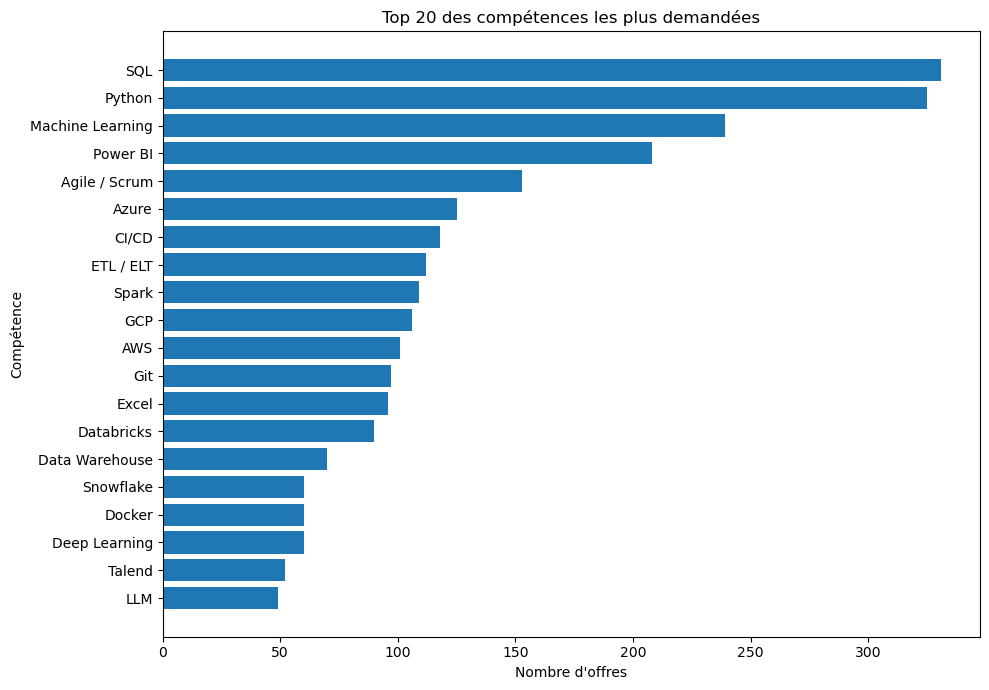

,competence,famille_competence,nombre_offres,part_offres
0,SQL,Bases de données,331,35.900217
1,Python,Langages,325,35.249458
2,Machine Learning,Machine Learning,239,25.921909
3,Power BI,BI et visualisation,208,22.559653
4,Agile / Scrum,Méthodes,153,16.594360
5,Azure,Cloud,125,13.557484
6,CI/CD,DevOps,118,12.798265
7,ETL / ELT,Data Engineering,112,12.147505
8,Spark,Data Engineering,109,11.822126
9,GCP,Cloud,106,11.496746


In [26]:
skill_stats = (
    skills_long
    .groupby(["competence", "famille_competence"])
    .agg(nombre_offres=("id", "nunique"))
    .reset_index()
)

skill_stats["part_offres"] = (
    skill_stats["nombre_offres"]
    / df["id"].nunique()
    * 100
)

skill_stats = skill_stats.sort_values(
    "nombre_offres",
    ascending=False,
).reset_index(drop=True)

top_skills = skill_stats.head(20).sort_values("nombre_offres")

plt.figure(figsize=(10, 7))
plt.barh(top_skills["competence"], top_skills["nombre_offres"])
plt.title("Top 20 des compétences les plus demandées")
plt.xlabel("Nombre d'offres")
plt.ylabel("Compétence")
plt.tight_layout()
plt.show()

skill_stats.head(20)

## 9. Répartition par famille de compétences

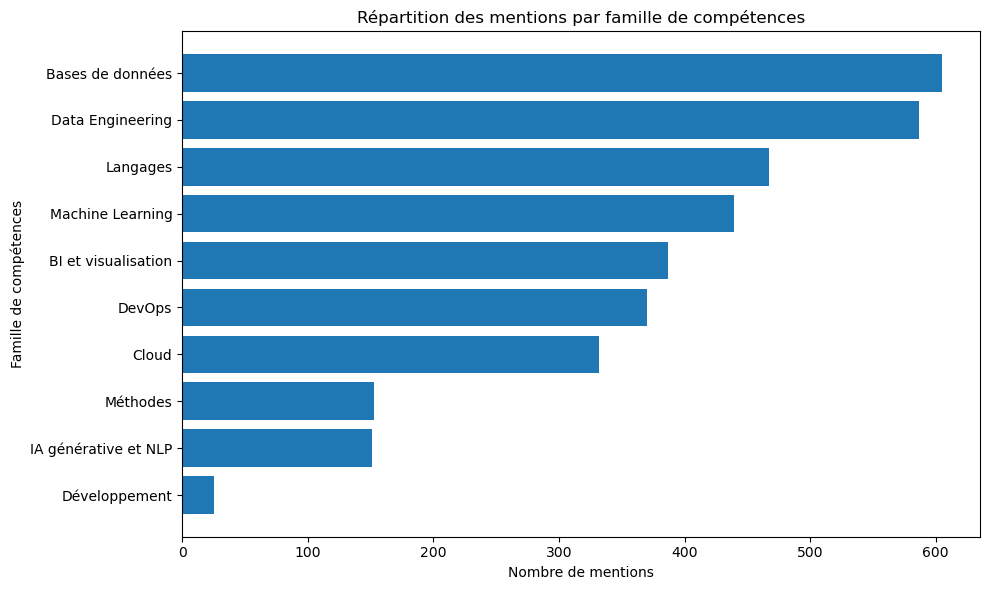

,nombre_mentions
famille_competence,
Bases de données,605
Data Engineering,587
Langages,467
Machine Learning,439
BI et visualisation,387
DevOps,370
Cloud,332
Méthodes,153
IA générative et NLP,151


In [29]:
family_stats = (
    skills_long
    .groupby("famille_competence")
    .agg(nombre_mentions=("id", "count"))
    .sort_values("nombre_mentions")
)

plt.figure(figsize=(10, 6))
plt.barh(family_stats.index, family_stats["nombre_mentions"])
plt.title("Répartition des mentions par famille de compétences")
plt.xlabel("Nombre de mentions")
plt.ylabel("Famille de compétences")
plt.tight_layout()
plt.show()

family_stats.sort_values(
    "nombre_mentions",
    ascending=False,
)

## 10. Compétences principales par métier

In [32]:
skills_by_job = (
    skills_long
    .groupby(["categorie_metier", "competence"])
    .agg(nombre_offres=("id", "nunique"))
    .reset_index()
)

top_skills_by_job = (
    skills_by_job
    .sort_values(
        ["categorie_metier", "nombre_offres"],
        ascending=[True, False],
    )
    .groupby("categorie_metier")
    .head(5)
    .reset_index(drop=True)
)

top_skills_by_job

,categorie_metier,competence,nombre_offres
0,Cloud / DevOps / Systems,CI/CD,9
1,Cloud / DevOps / Systems,Machine Learning,8
2,Cloud / DevOps / Systems,Docker,6
3,Cloud / DevOps / Systems,Python,6
4,Cloud / DevOps / Systems,Git,5
...,...,...,...
70,Software Engineering,Machine Learning,15
71,Software Engineering,Python,13
72,Software Engineering,SQL,11
73,Software Engineering,Java,8


## 11. Salaires associés aux compétences

Deux analyses complémentaires sont proposées :

- les compétences ayant les salaires médians les plus élevés ;
- les compétences clés du marché, même lorsqu'elles ne figurent pas dans le classement précédent.

Le nombre d'offres utilisées est affiché afin d'éviter d'interpréter une médiane calculée sur un échantillon trop faible.

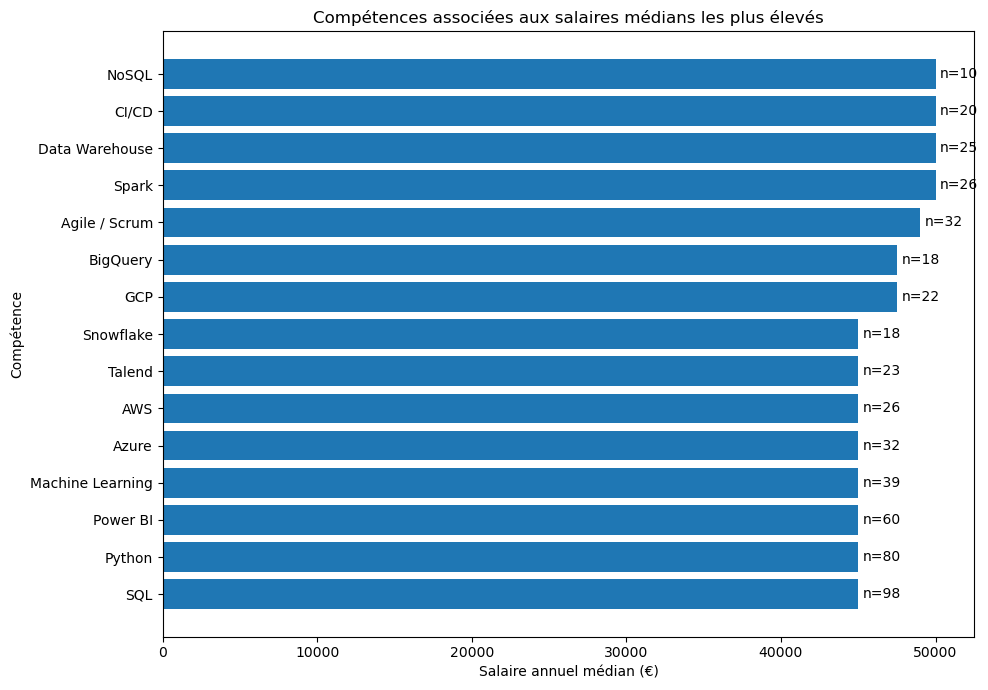

,competence,nombre_offres_salaire,salaire_median,salaire_moyen,fiabilite
48,Spark,26,50000.0,48942.307692,Moyenne
11,Data Warehouse,25,50000.0,45431.600000,Moyenne
9,CI/CD,20,50000.0,48100.000000,Moyenne
35,NoSQL,10,50000.0,49500.000000,Moyenne
2,Agile / Scrum,32,49000.0,46062.500000,Bonne
19,GCP,22,47500.0,47363.636364,Moyenne
6,BigQuery,18,47500.0,48194.444444,Moyenne
44,SQL,98,45000.0,44255.020408,Bonne
40,Python,80,45000.0,45731.250000,Bonne
38,Power BI,60,45000.0,43729.700000,Bonne


In [35]:
salary_by_skill = (
    skills_long
    .dropna(subset=["salaire_moy"])
    .groupby("competence")
    .agg(
        nombre_offres_salaire=("id", "nunique"),
        salaire_median=("salaire_moy", "median"),
        salaire_moyen=("salaire_moy", "mean"),
    )
    .reset_index()
)

salary_by_skill = salary_by_skill.sort_values(
    ["salaire_median", "nombre_offres_salaire"],
    ascending=[False, False],
)


def classify_reliability(sample_size):
    if sample_size >= 30:
        return "Bonne"

    if sample_size >= 10:
        return "Moyenne"

    return "Faible"


salary_by_skill["fiabilite"] = (
    salary_by_skill["nombre_offres_salaire"]
    .apply(classify_reliability)
)

minimum_salary_offers = 10

reliable_salary_skills = salary_by_skill[
    salary_by_skill["nombre_offres_salaire"] >= minimum_salary_offers
].copy()

top_salary_skills = (
    reliable_salary_skills
    .head(15)
    .sort_values("salaire_median")
)

if top_salary_skills.empty:
    print("Pas assez d'observations pour comparer les salaires.")
else:
    plt.figure(figsize=(10, 7))
    bars = plt.barh(
        top_salary_skills["competence"],
        top_salary_skills["salaire_median"],
    )

    for bar, sample_size in zip(
        bars,
        top_salary_skills["nombre_offres_salaire"],
    ):
        plt.text(
            bar.get_width() + 300,
            bar.get_y() + bar.get_height() / 2,
            f"n={sample_size}",
            va="center",
        )

    plt.title(
        "Compétences associées aux salaires médians les plus élevés"
    )
    plt.xlabel("Salaire annuel médian (€)")
    plt.ylabel("Compétence")
    plt.tight_layout()
    plt.show()

reliable_salary_skills.head(20)

## 12. Comparaison des compétences clés

Cette vue complète le classement précédent en suivant explicitement les compétences centrales du projet.

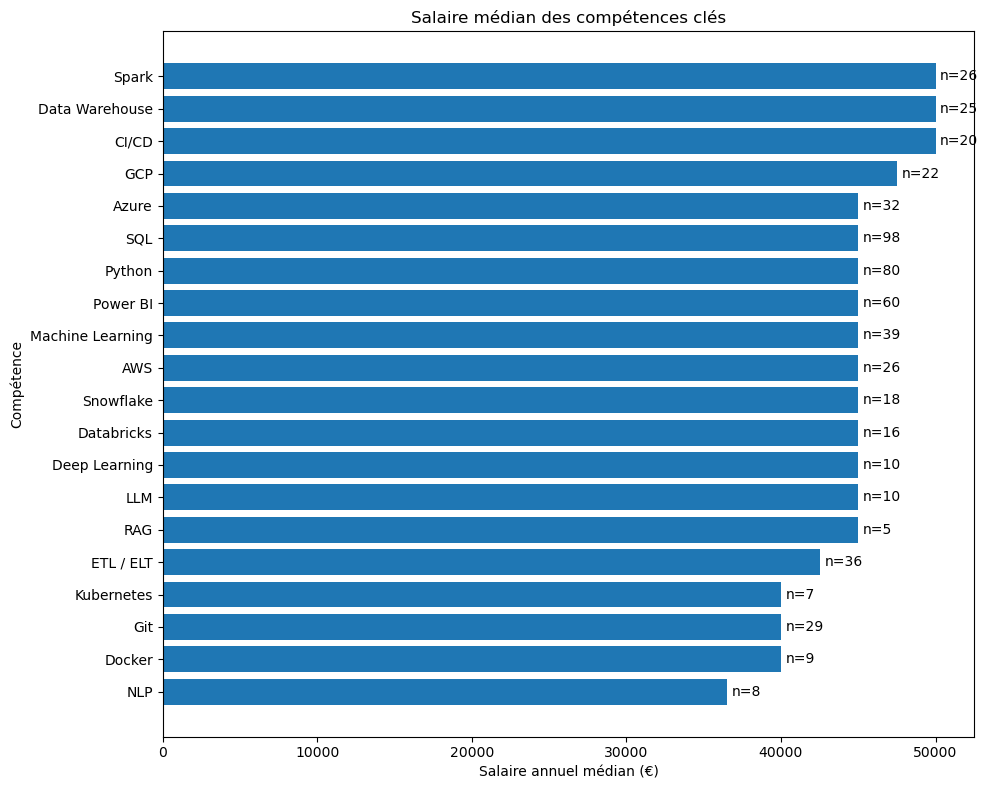

,competence,nombre_offres_salaire,salaire_median,salaire_moyen,fiabilite
0,Spark,26,50000.0,48942.307692,Moyenne
1,Data Warehouse,25,50000.0,45431.600000,Moyenne
2,CI/CD,20,50000.0,48100.000000,Moyenne
3,GCP,22,47500.0,47363.636364,Moyenne
4,Machine Learning,39,45000.0,46253.846154,Bonne
5,Azure,32,45000.0,46468.750000,Bonne
6,SQL,98,45000.0,44255.020408,Bonne
7,Python,80,45000.0,45731.250000,Bonne
8,Power BI,60,45000.0,43729.700000,Bonne
9,AWS,26,45000.0,45500.000000,Moyenne


In [38]:
KEY_SKILLS = [
    "Python",
    "SQL",
    "Power BI",
    "Machine Learning",
    "Deep Learning",
    "Spark",
    "Databricks",
    "Snowflake",
    "ETL / ELT",
    "Data Warehouse",
    "AWS",
    "Azure",
    "GCP",
    "Docker",
    "Kubernetes",
    "Git",
    "CI/CD",
    "NLP",
    "LLM",
    "RAG",
]

key_skill_salary = salary_by_skill[
    salary_by_skill["competence"].isin(KEY_SKILLS)
].copy()

key_skill_salary = key_skill_salary[
    key_skill_salary["nombre_offres_salaire"] >= 5
].sort_values("salaire_median")

if key_skill_salary.empty:
    print("Aucune compétence clé ne possède assez d'observations salariales.")
else:
    plt.figure(figsize=(10, 8))
    bars = plt.barh(
        key_skill_salary["competence"],
        key_skill_salary["salaire_median"],
    )

    for bar, sample_size in zip(
        bars,
        key_skill_salary["nombre_offres_salaire"],
    ):
        plt.text(
            bar.get_width() + 300,
            bar.get_y() + bar.get_height() / 2,
            f"n={sample_size}",
            va="center",
        )

    plt.title("Salaire médian des compétences clés")
    plt.xlabel("Salaire annuel médian (€)")
    plt.ylabel("Compétence")
    plt.tight_layout()
    plt.show()

key_skill_salary.sort_values(
    "salaire_median",
    ascending=False,
).reset_index(drop=True)

## 13. Export des résultats

In [41]:
OFFERS_OUTPUT_PATH = Path("offres_emploi_tech_skills.csv")
SKILLS_OUTPUT_PATH = Path("competences_offres.csv")
STATS_OUTPUT_PATH = Path("statistiques_competences.csv")

df_to_export = df.drop(
    columns=["texte_analyse", "competences_liste"]
)

df_to_export.to_csv(
    OFFERS_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

skills_long.to_csv(
    SKILLS_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

skill_stats.to_csv(
    STATS_OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Fichier offres : {OFFERS_OUTPUT_PATH}")
print(f"Fichier long : {SKILLS_OUTPUT_PATH}")
print(f"Statistiques : {STATS_OUTPUT_PATH}")

Fichier offres : offres_emploi_tech_skills.csv
Fichier long : competences_offres.csv
Statistiques : statistiques_competences.csv


## Conclusion

Cette méthode fournit une extraction transparente et facilement modifiable. Le dictionnaire peut être enrichi lorsque de nouvelles technologies apparaissent ou lorsqu'une inspection manuelle révèle des compétences manquantes.

Les fichiers exportés pourront être utilisés pour :

- construire le modèle de prédiction des salaires ;
- créer un classement des compétences ;
- calculer le Tech Skills Index.